# Decode RSC head direction with blocked cross-validation

This notebook adapts the first MLP decoder to a MATLAB-style blocked k-fold analysis. Each fold is a contiguous time block. The model is trained on all other blocks and produces out-of-sample predictions for the held-out block.


## What this notebook teaches

- **Blocked cross-validation（分块交叉验证）** for temporally ordered calcium data.
- Training one fresh MLP per fold.
- Fitting normalization statistics on the training portion of each fold only.
- Collecting out-of-sample predictions across the complete session.
- Evaluating circular HD error in degrees.

This first demonstration uses fixed training epochs. The held-out fold is not used for early stopping or hyperparameter selection.


In [1]:
# If imports fail, run this in a terminal from the project folder:
# pip install -r requirements.txt

from pathlib import Path
import math
import random

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

plt.style.use("seaborn-v0_8-whitegrid")
torch.set_float32_matmul_precision("high")

def seed_everything(seed=7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Choose one session and one cylinder window

The MATLAB script used `sessionList.xlsx` plus robust-cell tables to loop over many sessions. For learning PyTorch, start with one known session and all accepted CNMF-E components. Later, you can add robust-cell selection and cross-session loops.

In [2]:
DATA_ROOT = Path(r"D:/Shiyun_RSC_1p")
SESSION_NAME = "STIM1_2026_01_22_constantCue_acquisition"
SESSION_DIR = DATA_ROOT / SESSION_NAME

SESSION_DATA = SESSION_DIR / "sessionData.mat"
CNMFE_HDF5 = SESSION_DIR / "pipeline_cnmfe_results_2026-01-24_08-18.hdf5"

# MATLAB window labels: 0=pre-rotation, 1=post-rotation, 2=dark in Python indexing.
WINDOW_INDEX = 0
WINDOW_NAMES = ["pre rotation", "post rotation", "dark"]

# Set to None for no speed filtering in the first learning pass.
# MATLAB used speed_cri.of after lag alignment; you can add that later.
MIN_SPEED_PX_PER_S = None

assert SESSION_DATA.exists(), SESSION_DATA
assert CNMFE_HDF5.exists(), CNMFE_HDF5
SESSION_DATA, CNMFE_HDF5

(WindowsPath('D:/Shiyun_RSC_1p/STIM1_2026_01_22_constantCue_acquisition/sessionData.mat'),
 WindowsPath('D:/Shiyun_RSC_1p/STIM1_2026_01_22_constantCue_acquisition/pipeline_cnmfe_results_2026-01-24_08-18.hdf5'))

## MATLAB v7.3/HDF5 helpers

MATLAB v7.3 files are HDF5 files. Arrays are often stored with dimensions reversed relative to MATLAB display, so the helper below transposes 2D numeric datasets by default.

In [3]:
def read_matlab_h5_array(group, key, transpose_2d=True):
    """Read a numeric dataset from a MATLAB v7.3 struct group."""
    arr = np.array(group[key])
    arr = np.squeeze(arr)
    if transpose_2d and arr.ndim == 2:
        arr = arr.T
    return arr


def describe_h5_group(group, max_items=30):
    rows = []
    for key in list(group.keys())[:max_items]:
        obj = group[key]
        shape = getattr(obj, "shape", "")
        dtype = getattr(obj, "dtype", "")
        rows.append((key, shape, dtype))
    return pd.DataFrame(rows, columns=["key", "shape", "dtype"])


with h5py.File(SESSION_DATA, "r") as f:
    print(list(f.keys()))
    display(describe_h5_group(f["sessionData"]))
    display(describe_h5_group(f["sessionData"]["of"]))

['#refs#', '#subsystem#', 'sessionData']


,key,shape,dtype
0,Afs,"(4374, 37689)",float64
1,S,"(4374, 37689)",float64
2,calcium_time,"(37689, 1)",float64
3,idx_components,"(461, 1)",float64
4,maze,,
5,of,,
6,raw_C,"(4374, 37689)",float64


,key,shape,dtype
0,dark_flag,"(1, 1)",uint8
1,hd,"(37689, 1)",float64
2,raw_coord,"(2, 37689)",float64
3,segment_time,"(2, 4)",float64


In [4]:
def load_session_arrays(session_data_path, cnmfe_hdf5_path):
    with h5py.File(session_data_path, "r") as f:
        sd = f["sessionData"]
        of = sd["of"]

        calcium_time = read_matlab_h5_array(sd, "calcium_time", transpose_2d=False).astype(float)
        raw_C = read_matlab_h5_array(sd, "raw_C", transpose_2d=True).astype(np.float32)
        hd = read_matlab_h5_array(of, "hd", transpose_2d=False).astype(float)
        segment_time = read_matlab_h5_array(of, "segment_time", transpose_2d=True).astype(float)
        raw_coord = read_matlab_h5_array(of, "raw_coord", transpose_2d=True).astype(float)

    with h5py.File(cnmfe_hdf5_path, "r") as f:
        if "/estimates/idx_components" in f:
            accepted = np.array(f["/estimates/idx_components"]).astype(int).ravel()
        else:
            accepted = np.arange(raw_C.shape[1])

    # MATLAB added +1 because MATLAB is 1-based. Python keeps the HDF5 indices as 0-based.
    accepted = accepted[(accepted >= 0) & (accepted < raw_C.shape[1])]
    C = raw_C[:, accepted]
    C[C < 0] = 0

    return {
        "calcium_time": calcium_time,
        "C": C,
        "hd": hd,
        "segment_time": segment_time,
        "coord": raw_coord,
        "accepted_components": accepted,
    }


data = load_session_arrays(SESSION_DATA, CNMFE_HDF5)
{k: np.shape(v) for k, v in data.items() if k != "accepted_components"}, len(data["accepted_components"])

({'calcium_time': (37689,),
  'C': (37689, 461),
  'hd': (37689,),
  'segment_time': (4, 2),
  'coord': (37689, 2)},
 461)

## Match the MATLAB open-field and cylinder-window preprocessing

In the MATLAB code, open field is defined from the first open-field segment start through the second-to-last segment end. Calcium is min-max normalized within that open-field epoch. Then one cylinder window is selected from `segment_time`.

In [5]:
def minmax_normalize_columns(X):
    X = X.astype(np.float32, copy=True)
    lo = np.nanmin(X, axis=0, keepdims=True)
    hi = np.nanmax(X, axis=0, keepdims=True)
    denom = hi - lo
    denom[denom == 0] = 1
    return (X - lo) / denom


def circular_difference(a, b):
    return np.angle(np.exp(1j * (a - b)))


def compute_speed(coord, time_ms):
    dxy = np.diff(coord, axis=0)
    dt = np.diff(time_ms) / 1000.0
    speed = np.full(len(time_ms), np.nan)
    speed[1:] = np.sqrt((dxy ** 2).sum(axis=1)) / dt
    return speed


def prepare_window(data, window_index=0, min_speed_px_per_s=None):
    calcium_time = data["calcium_time"]
    segment_time = data["segment_time"]

    of_start = segment_time[0, 0]
    of_end = segment_time[-2, 1]
    of_flag = (calcium_time >= of_start) & (calcium_time <= of_end)

    of_time = calcium_time[of_flag]
    # Normalize across all open-field frames before selecting the window.
    of_C = minmax_normalize_columns(data["C"][of_flag])
    of_hd = data["hd"][of_flag]
    of_coord = data["coord"][of_flag]

    win_start, win_end = segment_time[window_index]
    win_flag = (of_time >= win_start) & (of_time <= win_end)

    X = of_C[win_flag]
    hd = of_hd[win_flag]
    time = of_time[win_flag]
    coord = of_coord[win_flag]

    finite = np.isfinite(hd) & np.all(np.isfinite(X), axis=1)
    if min_speed_px_per_s is not None:
        speed = compute_speed(coord, time)
        finite &= speed >= min_speed_px_per_s

    return X[finite], hd[finite], time[finite], coord[finite]


X, hd, time_ms, coord = prepare_window(data, WINDOW_INDEX, MIN_SPEED_PX_PER_S)
print(WINDOW_NAMES[WINDOW_INDEX])
print(f"frames: {X.shape[0]:,}")
print(f"accepted cells: {X.shape[1]:,}")
print(f"duration: {(time_ms[-1] - time_ms[0]) / 1000 / 60:.2f} min")


pre rotation
frames: 8,210
accepted cells: 461
duration: 13.95 min


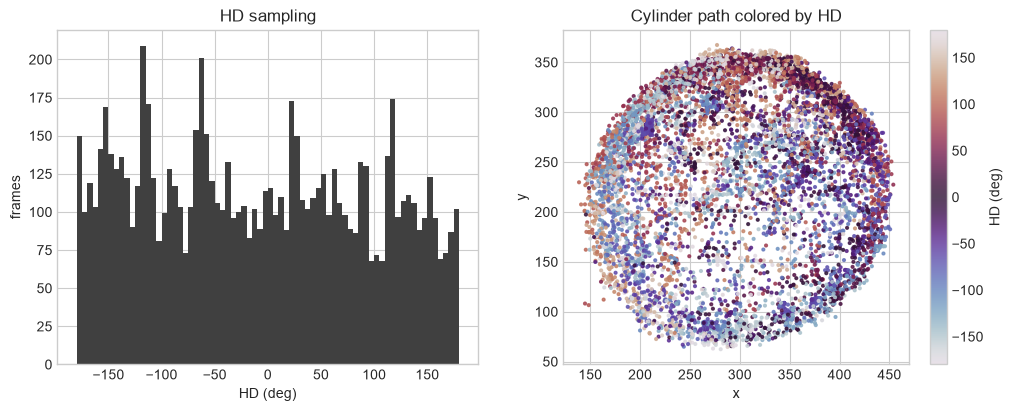

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].hist(np.rad2deg(hd), bins=72, color="0.25")
axes[0].set_xlabel("HD (deg)")
axes[0].set_ylabel("frames")
axes[0].set_title("HD sampling")

sc = axes[1].scatter(coord[:, 0], coord[:, 1], s=4, c=np.rad2deg(hd), cmap="twilight", alpha=0.8)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title("Cylinder path colored by HD")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

cbar = fig.colorbar(sc,ax=axes[1])
cbar.set_label("HD (deg)")

plt.show()

## Create a final test set and blocked cross-validation folds

The final test block is never used during cross-validation or model selection. The remaining development frames are divided into contiguous validation folds. Each fold trains on the other development blocks and validates on its held-out block.


In [7]:
def blocked_folds(indices, n_folds=5):
    if n_folds < 2 or n_folds > len(indices):
        raise ValueError("n_folds must be between 2 and the number of samples")
    return [fold.astype(int) for fold in np.array_split(indices, n_folds)]


N_FOLDS = 5
TEST_FRAC = 0.15
test_start = int(len(hd) * (1 - TEST_FRAC))

development_idx = np.arange(0, test_start)
test_idx = np.arange(test_start, len(hd))
folds = blocked_folds(development_idx, N_FOLDS)
y = np.column_stack([np.cos(hd), np.sin(hd)]).astype(np.float32)

print(f"development frames: {len(development_idx):,}")
print(f"final test frames: {len(test_idx):,}")
for fold_number, val_idx in enumerate(folds, start=1):
    print(
        f"fold {fold_number}: frames {val_idx[0]:,}-{val_idx[-1]:,} "
        f"({len(val_idx):,} validation frames)"
    )


development frames: 6,978
final test frames: 1,232
fold 1: frames 0-1,395 (1,396 validation frames)
fold 2: frames 1,396-2,791 (1,396 validation frames)
fold 3: frames 2,792-4,187 (1,396 validation frames)
fold 4: frames 4,188-5,582 (1,395 validation frames)
fold 5: frames 5,583-6,977 (1,395 validation frames)


## Dataset, model, and training helpers

The `FrameHDDataset` class is defined once. The `DataLoader` objects are created inside each fold because every fold has different training and validation indices.


In [8]:
class FrameHDDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [9]:
class HDDecoderMLP(nn.Module):
    def __init__(self, n_cells):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_cells, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        out = self.net(x)
        return nn.functional.normalize(out, dim=1)


def fit_zscore_normalization(X_train):
    # X has already received open-field min-max normalization.
    mu = X_train.mean(axis=0, keepdims=True)
    sigma = X_train.std(axis=0, keepdims=True)
    sigma[sigma == 0] = 1
    return mu, sigma


def apply_zscore_normalization(X_values, mu, sigma):
    return ((X_values - mu) / sigma).astype(np.float32)


loss_fn = nn.MSELoss()


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        with torch.set_grad_enabled(training):
            pred = model(xb)
            loss = loss_fn(pred, yb)

        if training:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(xb)
        n += len(xb)

    return total_loss / n


@torch.no_grad()
def predict_vectors(model, X_array, batch_size=1024):
    model.eval()
    predictions = []
    for start in range(0, len(X_array), batch_size):
        xb = torch.as_tensor(
            X_array[start:start + batch_size],
            dtype=torch.float32,
            device=device,
        )
        predictions.append(model(xb).cpu().numpy())
    return np.vstack(predictions)


## Train one model per blocked fold

For each fold, the training-derived `mu` and `sigma` are applied to that fold's training and validation data. The final test set is not used here.


In [10]:
BATCH_SIZE = 256
N_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

oof_pred_vec = np.full((len(X), 2), np.nan, dtype=np.float32)
fold_results = []
fold_histories = []

for fold_number, val_idx in enumerate(folds, start=1):
    train_idx = np.concatenate(
        [fold for i, fold in enumerate(folds) if i != fold_number - 1]
    )

    # Fit normalization only on this fold's training frames.
    mu, sigma = fit_zscore_normalization(X[train_idx])
    X_train_z = apply_zscore_normalization(X[train_idx], mu, sigma)
    X_val_z = apply_zscore_normalization(X[val_idx], mu, sigma)

    # These loaders are intentionally created inside the fold loop.
    train_loader = DataLoader(
        FrameHDDataset(X_train_z, y[train_idx]),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    val_loader = DataLoader(
        FrameHDDataset(X_val_z, y[val_idx]),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    model = HDDecoderMLP(X.shape[1]).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history = []
    for epoch in range(1, N_EPOCHS + 1):
        train_loss = run_epoch(model, train_loader, optimizer=optimizer)
        val_loss = run_epoch(model, val_loader)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
            }
        )

    # The held-out fold has never been used for weight updates.
    oof_pred_vec[val_idx] = predict_vectors(model, X_val_z)
    val_pred_hd = np.arctan2(oof_pred_vec[val_idx, 1], oof_pred_vec[val_idx, 0])
    val_err = circular_difference(val_pred_hd, hd[val_idx])
    val_mae_deg = np.abs(np.rad2deg(val_err)).mean()

    fold_results.append(
        {
            "fold": fold_number,
            "val_frames": len(val_idx),
            "final_train_mse": history[-1]["train_loss"],
            "final_val_mse": history[-1]["val_loss"],
            "val_mae_deg": val_mae_deg,
        }
    )
    fold_histories.append(history)
    print(f"fold {fold_number}/{N_FOLDS}: validation MAE = {val_mae_deg:.1f} deg")

fold_results_df = pd.DataFrame(fold_results)
fold_results_df


fold 1/5: validation MAE = 45.0 deg
fold 2/5: validation MAE = 28.8 deg
fold 3/5: validation MAE = 24.9 deg
fold 4/5: validation MAE = 33.6 deg
fold 5/5: validation MAE = 30.1 deg


,fold,val_frames,final_train_mse,final_val_mse,val_mae_deg
0,1,1396,0.009672,0.403750,45.043538
1,2,1396,0.010279,0.203442,28.797124
2,3,1396,0.009633,0.159809,24.870291
3,4,1395,0.009452,0.257331,33.596618
4,5,1395,0.011437,0.201005,30.100515


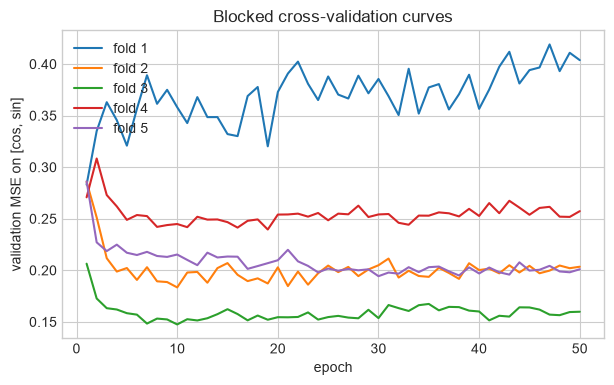

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
for fold_number, history in enumerate(fold_histories, start=1):
    hist_fold = pd.DataFrame(history)
    ax.plot(
        hist_fold["epoch"],
        hist_fold["val_loss"],
        label=f"fold {fold_number}",
    )
ax.set_xlabel("epoch")
ax.set_ylabel("validation MSE on [cos, sin]")
ax.set_title("Blocked cross-validation curves")
ax.legend()
plt.show()


## Out-of-sample cross-validation results


In [12]:
pred_hd = np.arctan2(oof_pred_vec[:, 1], oof_pred_vec[:, 0])
oof_mask = np.isfinite(oof_pred_vec).all(axis=1)
oof_err = circular_difference(pred_hd[oof_mask], hd[oof_mask])
oof_abs_err_deg = np.abs(np.rad2deg(oof_err))

print(f"mean blocked-CV absolute circular error: {oof_abs_err_deg.mean():.1f} deg")
print(f"median blocked-CV absolute circular error: {np.median(oof_abs_err_deg):.1f} deg")
print(
    f"fold MAE mean +/- SD: "
    f"{fold_results_df['val_mae_deg'].mean():.1f} +/- "
    f"{fold_results_df['val_mae_deg'].std(ddof=1):.1f} deg"
)


mean blocked-CV absolute circular error: 32.5 deg
median blocked-CV absolute circular error: 22.6 deg
fold MAE mean +/- SD: 32.5 +/- 7.7 deg


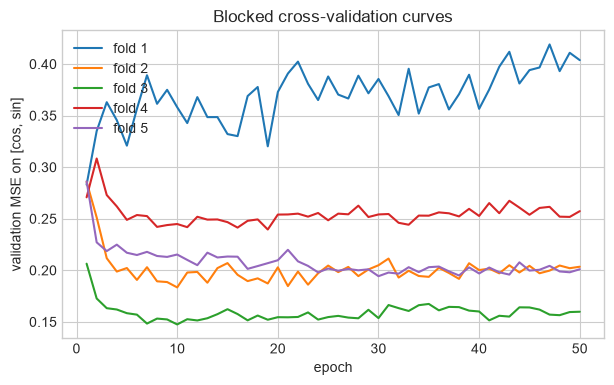

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
for fold_number, history in enumerate(fold_histories, start=1):
    hist_fold = pd.DataFrame(history)
    ax.plot(hist_fold["epoch"], hist_fold["val_loss"], label=f"fold {fold_number}")
ax.set_xlabel("epoch")
ax.set_ylabel("validation MSE on [cos, sin]")
ax.set_title("Blocked cross-validation curves")
ax.legend()
plt.show()


In [22]:
pred_hd[folds[-1]]

array([-1.2656496 , -0.93929774, -0.5355474 , ...,  2.7158637 ,
        2.733552  ,  2.670396  ], shape=(1395,), dtype=float32)

In [24]:
print(t_s.shape)
print(pred_hd.shape)

(8210,)
(8210,)


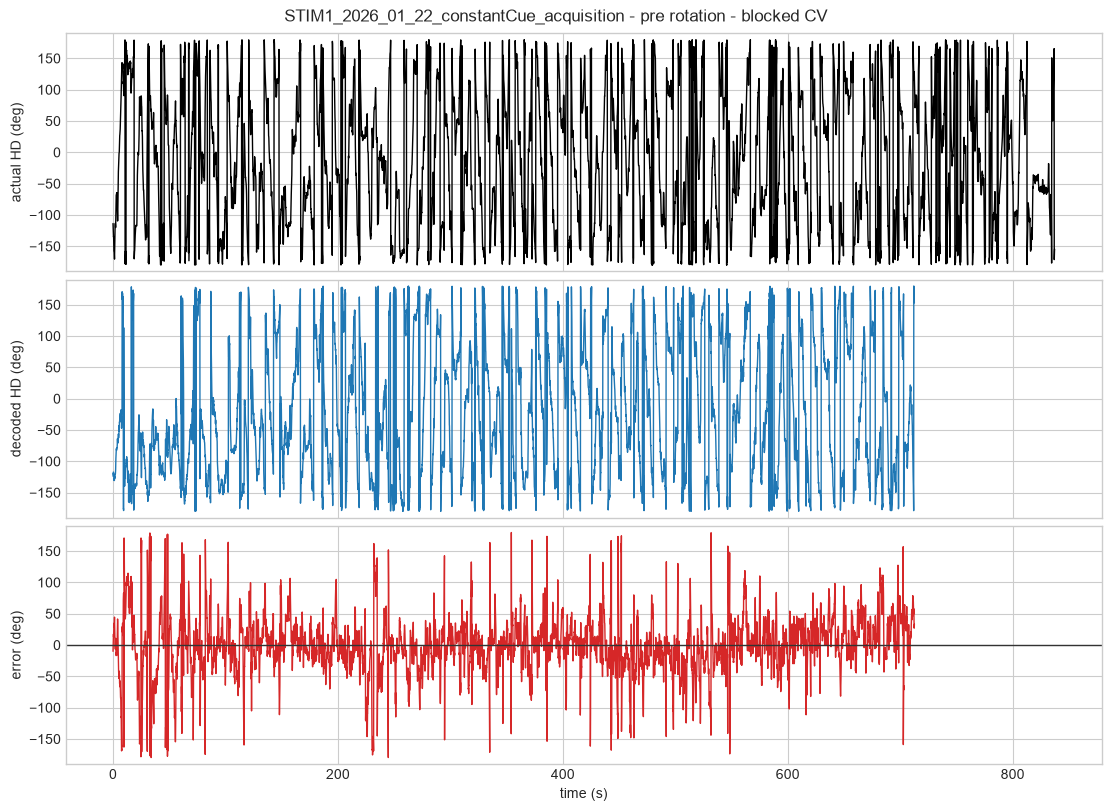

In [ ]:
t_s = (time_ms - time_ms[0]) / 1000

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, constrained_layout=True)
axes[0].plot(t_s, np.rad2deg(hd), lw=1, color="black")
axes[0].set_ylabel("actual HD (deg)")
axes[0].set_ylim(-190, 190)

axes[1].plot(t_s, np.rad2deg(pred_hd), lw=1, color="tab:blue")
axes[1].set_ylabel("decoded HD (deg)")
axes[1].set_ylim(-190, 190)

axes[2].plot(t_s[oof_mask], np.rad2deg(oof_err), lw=1, color="tab:red")
axes[2].axhline(0, color="0.2", lw=1)
axes[2].set_ylabel("error (deg)")
axes[2].set_xlabel("time (s)")
axes[2].set_ylim(-190, 190)

fig.suptitle(f"{SESSION_NAME} - {WINDOW_NAMES[WINDOW_INDEX]} - blocked CV")
plt.show()


## Train a final model and evaluate the untouched test block

After cross-validation, train one final model on all development frames. Its `mu` and `sigma` are fit using the development data, then applied to the test block. The test block is used only for this final evaluation.


In [25]:
mu_final, sigma_final = fit_zscore_normalization(X[development_idx])
X_development_z = apply_zscore_normalization(X[development_idx], mu_final, sigma_final)
X_test_z = apply_zscore_normalization(X[test_idx], mu_final, sigma_final)

final_train_loader = DataLoader(
    FrameHDDataset(X_development_z, y[development_idx]),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

final_model = HDDecoderMLP(X.shape[1]).to(device)
final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

final_history = []
for epoch in range(1, N_EPOCHS + 1):
    train_loss = run_epoch(final_model, final_train_loader, optimizer=final_optimizer)
    final_history.append({"epoch": epoch, "train_loss": train_loss})

test_pred_vec = predict_vectors(final_model, X_test_z)
test_pred_hd = np.arctan2(test_pred_vec[:, 1], test_pred_vec[:, 0])
test_err = circular_difference(test_pred_hd, hd[test_idx])
test_abs_err_deg = np.abs(np.rad2deg(test_err))

print(f"final test mean absolute circular error: {test_abs_err_deg.mean():.1f} deg")
print(f"final test median absolute circular error: {np.median(test_abs_err_deg):.1f} deg")


final test mean absolute circular error: 30.2 deg
final test median absolute circular error: 22.5 deg


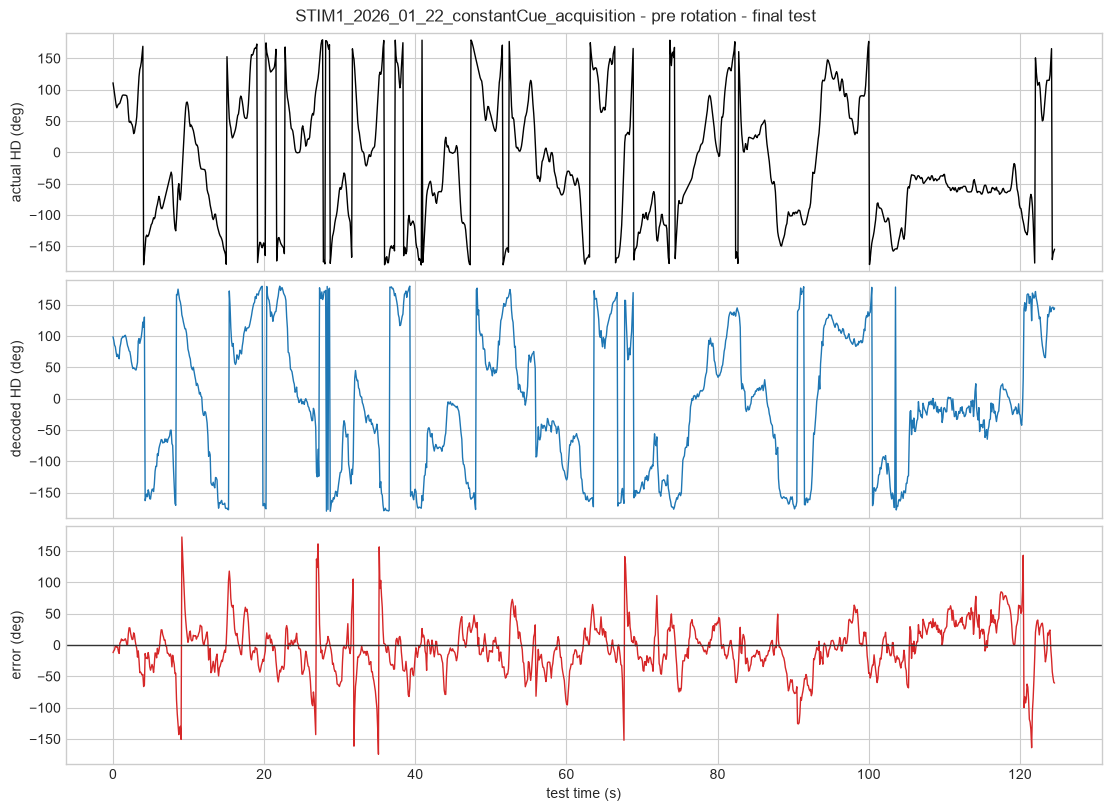

In [26]:
t_test_s = (time_ms[test_idx] - time_ms[test_idx][0]) / 1000

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, constrained_layout=True)
axes[0].plot(t_test_s, np.rad2deg(hd[test_idx]), lw=1, color="black")
axes[0].set_ylabel("actual HD (deg)")
axes[0].set_ylim(-190, 190)

axes[1].plot(t_test_s, np.rad2deg(test_pred_hd), lw=1, color="tab:blue")
axes[1].set_ylabel("decoded HD (deg)")
axes[1].set_ylim(-190, 190)

axes[2].plot(t_test_s, np.rad2deg(test_err), lw=1, color="tab:red")
axes[2].axhline(0, color="0.2", lw=1)
axes[2].set_ylabel("error (deg)")
axes[2].set_xlabel("test time (s)")
axes[2].set_ylim(-190, 190)

fig.suptitle(f"{SESSION_NAME} - {WINDOW_NAMES[WINDOW_INDEX]} - final test")
plt.show()
